# Monetary policy topics

Here we produce the results from lecture 6 using the SSJ toolkit

### Package setup

General python packages:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Import sequence-space Jacobian and pre-coded household block implementation

In [2]:
import sequence_jacobian as sj
import sim_steady_state_fast as sim
hh = sj.hetblocks.hh_sim.hh

Now some commands to format plot output to look nice for slides.

In [3]:
plt.rcParams.update({'font.size': 10, 'font.family': 'serif', 'figure.figsize': (6, 3)})
plt.rcParams.update({'text.usetex': True, 'font.serif': 'Palatino'})
# Shade of blue colors
colors = plt.cm.Blues(np.linspace(0.5, 1, 4)[::-1])

## Import calibration, compute household steady state

In [4]:
from calibration import make_calibration
calib, e = make_calibration(lowA=True)

# Compute steady state using the hetblock steady_state functionality
ss_hh = hh.steady_state(calib)
print(f"Steady state: r={ss_hh['r']:.4f}, C={ss_hh['C']:.4f}, A={ss_hh['A']:.4f}")

Steady state: r=0.0050, C=0.7200, A=4.0000


In [5]:
# Time horizon for impulse responses
T = 400

## Warmup: replicate lecture 4 results with SSJ

In [6]:
# Turn income into a hetblock input
def income(Y,T, e_grid):
    y = (Y-T) * e_grid
    return y
hh_ge_simple = hh.add_hetinputs([income])

@sj.simple
def fiscal(r_ante, Tss, Bss, rss):
    """Implement fiscal rule"""
    T = Tss + (r_ante - rss)/(1+r_ante)*Bss
    B = (1+rss)/(1+r_ante)*Bss
    return T,B

@sj.simple
def ex_post_r(r_ante):
    """Calculate ex-poste real rate from ex-ante rate"""
    r = r_ante(-1)
    return r

@sj.simple
def mkt_clearing(A, Y, C, B, G):
    """Market clearing conditions"""
    asset_mkt = A - B
    goods_mkt = C + G - Y
    return asset_mkt, goods_mkt

blocks = [hh_ge_simple, ex_post_r, fiscal, mkt_clearing]

model = sj.combine(blocks, name='lecture4')

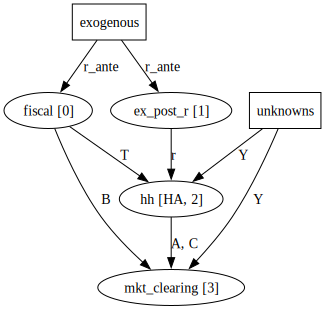

In [7]:
sj.drawdag(model, exogenous=['r_ante'], unknowns=['Y'])

In [8]:
calib = {**calib,
      'r_ante':calib['r'],
      'e_grid': e,
      'Y':1,
      'T':1-0.7,
      'B':ss_hh['A'],
      'G':1-ss_hh['C'],
}

#Fill in steady state numbers used in fiscal rule
calib = {**calib,
      'rss':calib['r'],
      'Tss':calib['T'],
      'Bss':calib['B']
}

# Check steady-state government budget constraint
assert(np.abs(calib['T']-calib['G']-calib['r']*calib['B']) < 1e-7)

#calib
ss = model.steady_state(calib)
print('Asset market residual:', ss['asset_mkt'])
print('Goods market residual:', ss['goods_mkt'])

Asset market residual: 0.0
Goods market residual: 0.0


Household Jacobian to r_ante

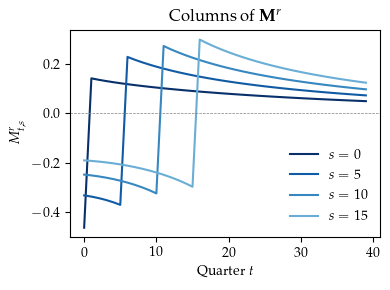

In [9]:
hh_combined = sj.combine([hh_ge_simple, ex_post_r], name='combined household')
J = hh_combined.jacobian(ss, inputs=['r_ante','Y'], outputs=['C'],T=T)
Mr = J['C']['r_ante']
M = J['C']['Y']

plt.figure(figsize=(4, 3))
for i, s in enumerate([0, 5, 10, 15]):
    plt.plot(Mr[:40, s], label=f'$s={s}$', color=colors[i])
plt.xlabel('Quarter $t$')
plt.ylabel(r'$M^r_{t,s}$')
plt.title(r'Columns of $\mathbf{M}^r$')
plt.legend(frameon=False)
plt.tight_layout()
plt.axhline(0, linestyle='--', color='grey', linewidth=0.5);

Impulse response to monetary shock

In [10]:
dr = -0.25 * 0.9**np.arange(T)  # Compared to lecture 4, now "dr" is the **level** effect on $r$
irfs = model.solve_impulse_linear(ss, unknowns=['Y'], targets=['asset_mkt'], inputs = {'r_ante': dr})

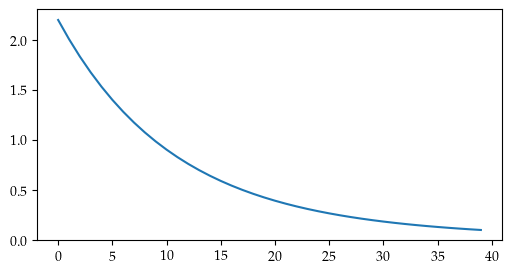

In [11]:
plt.plot(irfs['Y'][:40], label='Equilibrium output response to $r$ shock'); 

Check impulse response against lecture 4 

In [12]:
irfs['Y'][0:5]

array([2.20164142, 2.01040214, 1.83640493, 1.67813979, 1.53417228])

Also replicate forward guidance shock

In [13]:
Tfg = 20
dr = np.zeros(T)
dr[Tfg] = -0.25 

irfs = model.solve_impulse_linear(ss, unknowns=['Y'], targets=['asset_mkt'], inputs = {'r_ante': dr})

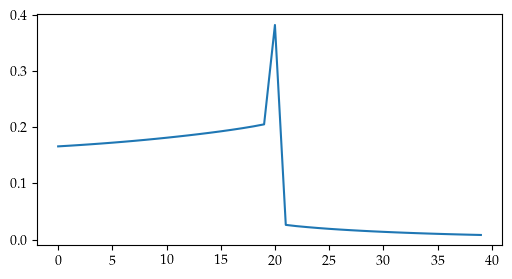

In [14]:
plt.plot(irfs['Y'][:40], label='Equilibrium output response to $r$ shock')

In [15]:
irfs['Y'][0:5]

array([0.16598118, 0.16714329, 0.16838044, 0.16969395, 0.17108747])

## Cyclical income risk

In [16]:
def income_cyclical(Y,T, e_grid, e_pdf, zeta):
    y = (Y-T) * e_grid ** (1 + zeta * np.log(Y)) / np.vdot(e_grid ** (1 + zeta * np.log(Y)), e_pdf)
    return y

household_cyc = hh.add_hetinputs([income_cyclical])

print('Household block inputs:' , household_cyc.inputs)
print('Household block outputs:' , household_cyc.outputs)

Household block inputs: ['a_grid', 'r', 'beta', 'eis', 'Pi', 'Y', 'T', 'e_grid', 'e_pdf', 'zeta']
Household block outputs: ['A', 'C']


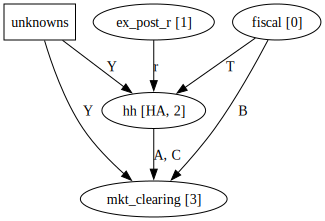

In [17]:
model_cyc = sj.create_model([household_cyc, ex_post_r, fiscal, mkt_clearing], \
                         name="HA Model with cyclical income risk")

sj.drawdag(model_cyc, unknowns=['Y'])

In [18]:
calib_cyc = calib.copy()
# Need the pdf of e for income_cyclical
calib_cyc['e_pdf'] = sim.stationary_markov(ss['Pi'])
calib_cyc['zeta'] = - 1

calib_pro = calib_cyc.copy()
calib_pro['zeta'] = 1

#calib
ss_cyc = model_cyc.steady_state(calib_cyc)
print('Asset market residual:', ss_cyc['asset_mkt'])
print('Goods market residual:', ss_cyc['goods_mkt'])

#calib
ss_pro = model_cyc.steady_state(calib_pro)
print('Asset market residual:', ss_pro['asset_mkt'])
print('Goods market residual:', ss_pro['goods_mkt'])

Asset market residual: -3.540279180924699e-12
Goods market residual: -6.374900607397649e-13
Asset market residual: -3.540279180924699e-12
Goods market residual: -6.374900607397649e-13


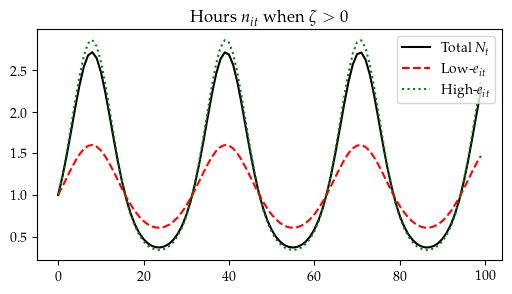

In [19]:
e_grid_cyc, e_pdf_cyc = calib_cyc['e_grid'], calib_cyc['e_pdf']
low_e = np.argmin(np.abs(e_grid_cyc - 0.1))
high_e = np.argmin(np.abs(e_grid_cyc - 2))

def cyclical_hours(logY, zeta):
    Y_path = np.exp(logY)
    y_path = np.vstack([income_cyclical(Y, 0, e_grid_cyc, e_pdf_cyc, zeta) for Y in Y_path])
    return Y_path, y_path[:, low_e] / e_grid_cyc[low_e], y_path[:, high_e] / e_grid_cyc[high_e]

zeta = 0.2
logY = np.sin(np.arange(100)/5)
N, n_low, n_high = cyclical_hours(logY, zeta)

plt.plot(N, label=r'Total $N_t$', color='black')
plt.plot(n_low, label=fr'Low-$e_{{it}}$', color='red', linestyle='dashed')
plt.plot(n_high, label=fr'High-$e_{{it}}$', color='green', linestyle='dotted')
plt.legend()
plt.title(r'Hours $n_{it}$ when $\zeta>0$');
plt.savefig('figures/lecture6_n_zeta_pos.pdf', transparent=True, bbox_inches='tight')

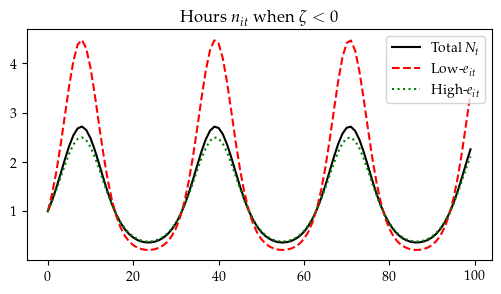

In [20]:
zeta = -0.2
N, n_low, n_high = cyclical_hours(logY, zeta)

plt.plot(N, label=r'Total $N_t$', color='black')
plt.plot(n_low, label=fr'Low-$e_{{it}}$', color='red', linestyle='dashed')
plt.plot(n_high, label=fr'High-$e_{{it}}$', color='green', linestyle='dotted')
plt.legend()
plt.title(r'Hours $n_{it}$ when $\zeta<0$');
plt.savefig('figures/lecture6_n_zeta_neg.pdf', transparent=True, bbox_inches='tight')

Check that zeta does not change the steady state

In [21]:
assert np.allclose(ss['beta'], ss_cyc['beta'])
assert np.allclose(ss['beta'], ss_pro['beta'])

In [22]:
irfs_cyc = model_cyc.solve_impulse_linear(ss_cyc, unknowns=['Y'], targets=['asset_mkt'], inputs = {'r_ante': dr})
irfs_pro = model_cyc.solve_impulse_linear(ss_pro, unknowns=['Y'], targets=['asset_mkt'], inputs = {'r_ante': dr})

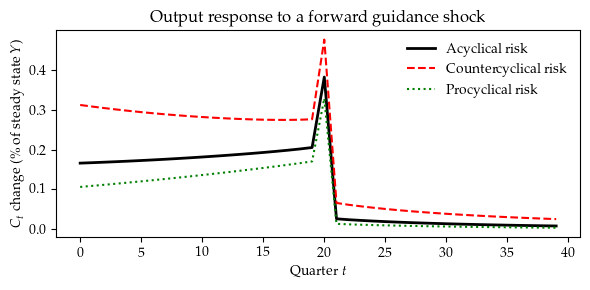

In [23]:
plt.plot(irfs['Y'][:40], label='Acyclical risk', color='black', linewidth=2)
plt.plot(irfs_cyc['Y'][:40], label='Countercyclical risk', color='red', linestyle='dashed')
plt.plot(irfs_pro['Y'][:40], label='Procyclical risk', color='green', linestyle='dotted')
plt.xlabel('Quarter $t$')
plt.ylabel('Output response')
plt.title('Output response to a forward guidance shock')
plt.legend(frameon=False)
plt.tight_layout()
plt.ylabel(r'$C_t$ change (\% of steady state $Y$)')
plt.xlabel(r'Quarter $t$')
plt.savefig('figures/lecture6_fg_counter.pdf', transparent=True, bbox_inches='tight')


## Long-term debt

Add blocks determining price from ex-ante rate and ex-post rate from price: 

In [24]:
@sj.solved(unknowns={'q': (0.1, 25)}, targets=['qres'], solver="brentq")
def price_longbonds(q, r_ante, delta):
    qres = q - (1 + delta * q(+1)) / (1 + r_ante)
    return qres

@sj.simple
def ex_post_r_longbonds(q, delta):
    r = (1 + delta * q)/q(-1) - 1
    return r


Modify fiscal rule to be consistent with constant-coupon target $\lambda_t = \lambda_{ss}$ 

In [25]:
@sj.simple
def fiscal_longbonds(q, delta, Bss, Gss):
    """Implement fiscal rule that keeps coupons constant"""
    T = Gss + (1+delta*q-q)*Bss/q.ss
    B = q*Bss/q.ss
    return T,B

Declare model 

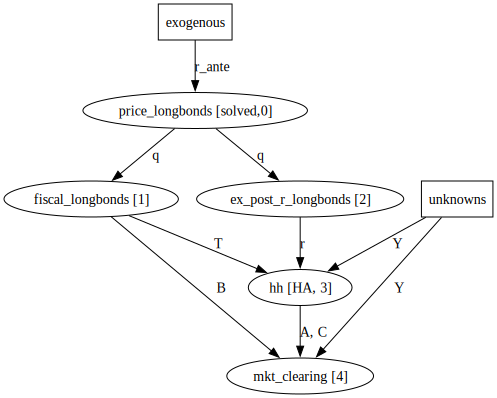

In [26]:
blocks_lt = [hh_ge_simple, price_longbonds, ex_post_r_longbonds, fiscal_longbonds, mkt_clearing]
model_lt = sj.create_model(blocks_lt, \
                         name="HA Model with long-term bonds")

sj.drawdag(model_lt, exogenous=['r_ante'], unknowns=['Y'])

Calibrate

In [27]:
calib_lt = calib.copy()
calib_lt['delta'] = 0.9
calib_lt['Gss'] = calib_lt['G']

Solve steady state

In [28]:
ss_lt = model_lt.steady_state(calib_lt)
# Check bond price
assert(ss_lt['q']==1/(1+calib_lt['r']-calib_lt['delta']))

Solve monetary shock in short vs long bond model 

In [29]:
dr = -0.25 * 0.9**np.arange(T)  # Compared to lecture 4, now "dr" is the **level** effect on $r$
irfs = model.solve_impulse_linear(ss, unknowns=['Y'], targets=['asset_mkt'], inputs = {'r_ante': dr})
irfs_lt = model_lt.solve_impulse_linear(ss_lt, unknowns=['Y'], targets=['asset_mkt'], inputs = {'r_ante': dr})

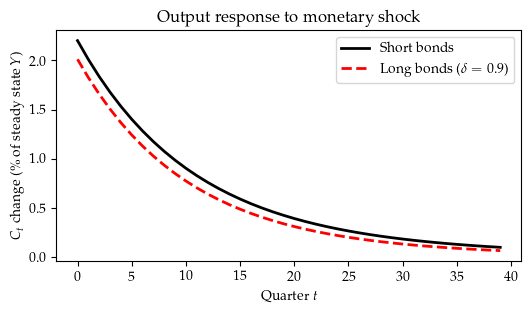

In [30]:
plt.plot(irfs['Y'][:40], label='Short bonds', color='black', linewidth=2)
plt.plot(irfs_lt['Y'][:40], label=r'Long bonds ($\delta=0.9$)', color='red', linestyle='--', linewidth=2)
plt.xlabel('Quarter $t$')
plt.ylabel(r'$C_t$ change (\% of steady state $Y$)')
plt.title('Output response to monetary shock')
plt.legend()
plt.savefig('figures/lecture6_longbonds.pdf', transparent=True, bbox_inches='tight')

Solve for steady state with various deltas

In [31]:
deltavec = np.linspace(0, 0.99, 10)
qvec = 1/(1+calib_lt['r']-deltavec)
irf_lt_dict = {}

for delta, q in zip(deltavec, qvec):
    ss_lt['delta']=delta
    ss_lt['q']=q
    irf_lt_dict[delta] = model_lt.solve_impulse_linear(ss_lt, unknowns=['Y'], targets=['asset_mkt'], inputs = {'r_ante': dr})
    print(f"delta={delta:.2f}, q={q:.4f}, output response at t=0: {irf_lt_dict[delta]['Y'][0]:.4f}")

delta=0.00, q=0.9950, output response at t=0: 2.2016
delta=0.11, q=1.1173, output response at t=0: 2.1967
delta=0.22, q=1.2739, output response at t=0: 2.1904
delta=0.33, q=1.4815, output response at t=0: 2.1825
delta=0.44, q=1.7699, output response at t=0: 2.1720
delta=0.55, q=2.1978, output response at t=0: 2.1574
delta=0.66, q=2.8986, output response at t=0: 2.1357
delta=0.77, q=4.2553, output response at t=0: 2.1003
delta=0.88, q=8.0000, output response at t=0: 2.0320
delta=0.99, q=66.6667, output response at t=0: 1.8451


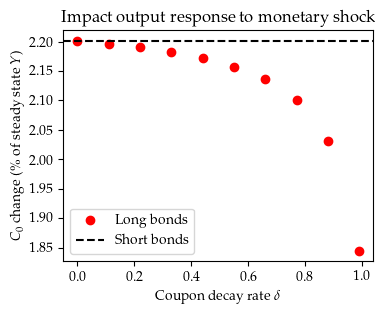

In [32]:
plt.figure(figsize=(4, 3))
plt.scatter(deltavec, [irf_lt_dict[delta]['Y'][0] for delta in deltavec], color='red', marker='o', label='Long bonds')
plt.axhline(irfs['Y'][0], label='Short bonds', color='black', linestyle='dashed')
plt.xlabel(r'Coupon decay rate $\delta$')
plt.ylabel(r'$C_0$ change (\% of steady state $Y$)')
plt.title('Impact output response to monetary shock')
plt.legend()
plt.savefig('figures/lecture6_longbonds_varydelta.pdf', transparent=True, bbox_inches='tight')

## Nominal assets

In [33]:
@sj.simple
def nkpc(pi, Y, kappa_w, beta_avg):
    piw = pi
    piwres = kappa_w * (Y-Y.ss) + beta_avg * piw(1) - piw
    return piwres, piw


@sj.simple
def ex_post_r_nom(r_ante, pi):
    # i = (1+r_ante) * (1+pi(1))
    # r = (1+i(-1))/(1+pi)
    i = r_ante + pi(1)
    r = i(-1) - pi
    return r

@sj.simple
def fiscal_nom(r, r_ante, Gss, Bss, rss):
    """Implement fiscal rule"""
    Bpast = (1+rss)/(1+r_ante(-1))*Bss
    B = (1+rss)/(1+r_ante)*Bss
    T = Gss + (1+r)*Bpast - B
    return T,B

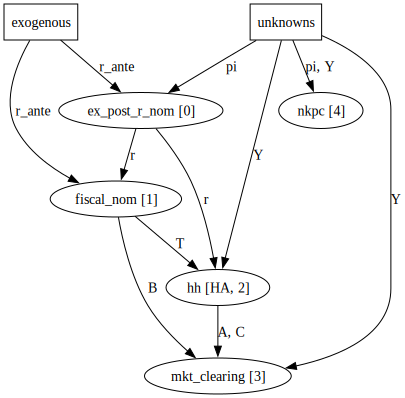

In [34]:
blocks_nom = [hh_ge_simple, nkpc, ex_post_r_nom, fiscal_nom, mkt_clearing]
model_nom = sj.create_model(blocks_nom, \
                         name="HA Model with nominal bonds")

sj.drawdag(model_nom, exogenous=['r_ante'], unknowns=['Y', 'pi'])

In [35]:
calib_nom = calib.copy()
calib_nom['pi'] = 0. 
calib_nom['kappa_w'] = 0.1 
calib_nom['Gss'] = calib['G']
# Calculate average beta for Phillips curve
calib_nom['beta_avg'] = np.vdot(calib['beta'], sim.stationary_markov(ss['Pi']))

In [36]:
ss_nom = model_nom.steady_state(calib_nom)

In [37]:
irfs_nom = model_nom.solve_impulse_linear(ss_nom, unknowns=['Y', 'pi'], targets=['asset_mkt', 'piwres'], inputs = {'r_ante': dr})


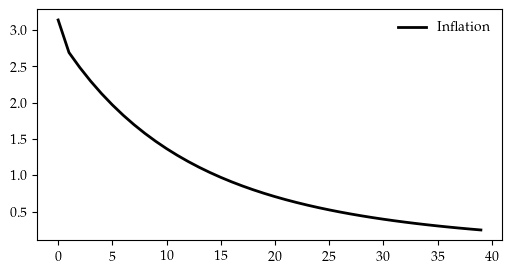

In [38]:
plt.plot(irfs_nom['pi'][:40], label='Inflation', color='black', linewidth=2);
plt.legend(frameon=False);


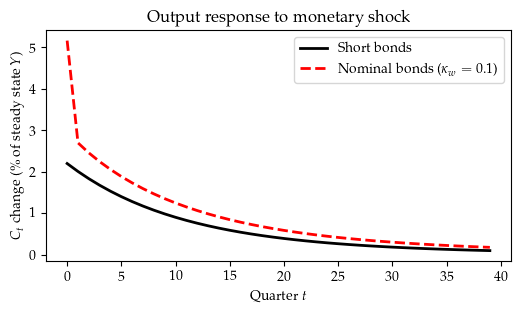

In [39]:
plt.plot(irfs['Y'][:40], label='Short bonds', color='black', linewidth=2)
plt.plot(irfs_nom['Y'][:40], label=r'Nominal bonds ($\kappa_w=0.1$)', color='red', linestyle='--', linewidth=2)
plt.xlabel('Quarter $t$')
plt.ylabel(r'$C_t$ change (\% of steady state $Y$)')
plt.title('Output response to monetary shock')
plt.legend()
plt.savefig('figures/lecture6_nombonds.pdf', transparent=True, bbox_inches='tight')

## The stock market

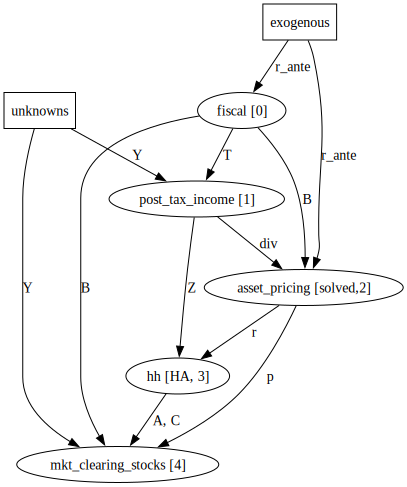

In [40]:
def income(Z, e_grid):
    y = Z * e_grid
    return y
hh_ge_z = hh.add_hetinputs([income])

@sj.simple
def post_tax_income(Y, T, mu):
    Z = (Y-T) / mu
    div = (1-1/mu)*(Y - T)
    return Z, div

@sj.simple
def fiscal(r_ante, Tss, Bss, rss):
    """Implement fiscal rule"""
    T = Tss + (r_ante - rss)/(1+r_ante)*Bss
    B = (1+rss)/(1+r_ante)*Bss
    return T,B

@sj.solved(unknowns={'p': (0.001,100)}, targets=['cap_cond'])
def asset_pricing(div, r_ante, p, B):
    """Calculate end-of-period value p of firm and ex-post return on equity holdings"""
    cap_cond = p - (div(+1) + p(+1))/(1 + r_ante)
    r_equity = (div + p)/p(-1) - 1
    r = (p(-1) * r_equity + B(-1) * r_ante(-1)) / (p(-1) + B(-1))
    return r_equity, r, cap_cond

@sj.simple
def mkt_clearing_stocks(A, Y, C, p, B, G):
    """Market clearing conditions"""
    asset_mkt = A - p - B
    goods_mkt = C + G - Y
    return asset_mkt, goods_mkt

blocks_stocks = [hh_ge_z, fiscal, post_tax_income, asset_pricing, mkt_clearing_stocks]
model_stocks = sj.create_model(blocks_stocks, \
                         name="HA Model with stocks")

sj.drawdag(model_stocks, exogenous=['r_ante'], unknowns=['Y'])

In [41]:
calib_stock, e_stock = make_calibration(lowA=False)

# Compute steady state using the hetblock steady_state functionality
ss_hh_stock = hh.steady_state(calib_stock)
print(f"Steady state: r={ss_hh_stock['r']:.4f}, C={ss_hh_stock['C']:.4f}, A={ss_hh_stock['A']:.4f}")

Steady state: r=0.0050, C=0.8000, A=20.0000


Calibration

In [42]:
Y = 1
B = 4
Z = 0.7
r = ss_hh_stock['r']
A = ss_hh_stock['A']
G = Y-ss_hh_stock['C']
Tax = G + r*B
mu = (Y-Tax)/Z

calib_stock = {**calib_stock,
      'r_ante': r,
      'e_grid': e_stock,
      'Y':Y,
      'B':B,
      'Z':Z,
      'A':A,
      'G':G,
      'T':Tax,
      'mu':mu,
}

#Fill in steady state numbers used in fiscal rule
calib_stock = {**calib_stock,
      'rss':r,
      'Tss':Tax,
      'Bss':B
}

# # Check steady-state government budget constraint
assert(np.abs(calib_stock['T']-calib_stock['G']-calib_stock['r']*calib_stock['B']) < 1e-7)

# Calibrate
ss_stock = model_stocks.steady_state(calib_stock)
print('Asset market residual:', ss_stock['asset_mkt'])
print('Goods market residual:', ss_stock['goods_mkt'])

# # Check asset price is what we expect, p=div/r
assert(np.abs(ss_stock['p']-ss_stock['div']/ss_stock['r']) < 1e-7)

Asset market residual: -7.936404917785467e-05
Goods market residual: 0.0


In [43]:
print(f"Steady state: p={ss_stock['p']:.4f}, B={ss_stock['B']:.4f}")
print(f"Steady state: T={ss_stock['T']:.4f}, mu={ss_stock['mu']:.4f}")

Steady state: p=16.0001, B=4.0000
Steady state: T=0.2200, mu=1.1143


Get Jacobians and visualize $M,Mr$

In [44]:
T=400
Js = hh_ge_z.jacobian(ss_stock, inputs=['Z', 'r'], outputs=['C', 'A'], T=T)

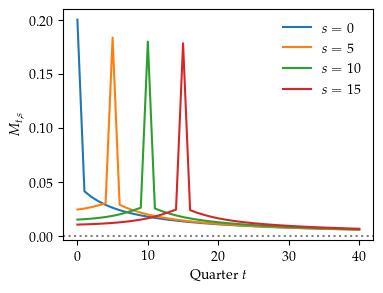

In [45]:
plt.figure(figsize=(4, 3))
for s in (0, 5, 10, 15):
    plt.plot(Js['C']['Z'][:41,s], label=fr'$s={s}$')
plt.axhline(y=0, linestyle='dotted', color='gray')
plt.xlabel(r'Quarter $t$')
plt.ylabel(r'$M_{t,s}$')
plt.legend(frameon=False)

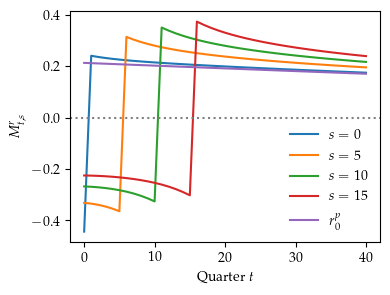

In [46]:
plt.figure(figsize=(4, 3))
for s in (1, 6, 11, 16):
    plt.plot(Js['C']['r'][:41,s], label=fr'$s={s-1}$')
plt.plot(Js['C']['r'][:41,0], label=fr'$r_0^p$')
plt.axhline(y=0, linestyle='dotted', color='gray')
plt.xlabel(r'Quarter $t$')
plt.ylabel(r'$M^r_{t,s}$')
plt.legend(frameon=False)

Impulse response to monetary shock

In [47]:
dr = -0.25 * 0.9**np.arange(T)
shock_r = {'r_ante': dr}

irfs = model_stocks.solve_impulse_linear(ss_stock, unknowns=['Y'], targets=['asset_mkt'],
                                inputs=shock_r)

Walras's law check

In [48]:
irfs['goods_mkt'][:5]

array([-1.67123627e-04,  1.97422955e-05,  1.77680657e-05,  1.59912593e-05,
        1.43921332e-05])

In [49]:
dC_cap_gains = Js['C','r'][:, 0] * irfs['r'][0]
dC_r = Js['C','r'][:, 1:] @ irfs['r'][1:]
dC_labor = Js['C', 'Z'] @ irfs['Y']/mu
dC_tax = -Js['C', 'Z'] @ irfs['T']/mu
assert np.allclose(dC_cap_gains + dC_r + dC_labor + dC_tax, irfs['C'])

Report the MPC out of capital gains

In [63]:
Js['C','r'][0:5, 0]/ss_stock['A']

array([0.01064391, 0.01058961, 0.01053529, 0.01048128, 0.01042754])

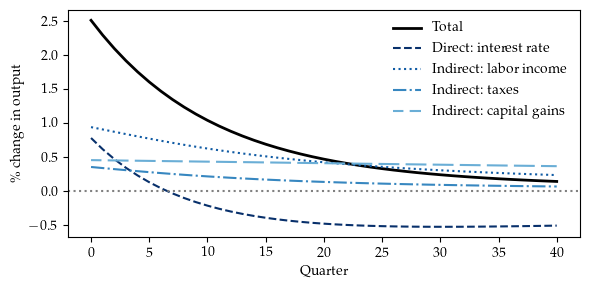

In [51]:
plt.plot(irfs['C'][:41], label='Total', color='black', linewidth=2)
plt.plot(dC_r[:41], label='Direct: interest rate', linestyle='dashed', color=colors[0])
plt.plot(dC_labor[:41], label='Indirect: labor income', linestyle='dotted', color=colors[1])
plt.plot(dC_tax[:41], label='Indirect: taxes', linestyle='dashdot', color=colors[2])
plt.plot(dC_cap_gains[:41], label='Indirect: capital gains', linestyle=(5, (10, 3)), color=colors[3])
plt.axhline(y=0, linestyle='dotted', color='gray')
plt.legend(frameon=False)
plt.tight_layout()
plt.xlabel('Quarter')
plt.ylabel(r'\% change in output')
plt.tight_layout()
plt.savefig('figures/lecture6_decomposition_stock.pdf', transparent=True, bbox_inches='tight')

Now do this in the model with no bonds and pure stocks

In [52]:
B = 0
Tax = G + r*B
mu = (Y-Tax)/Z

calib_stock_only = {**calib_stock,
      'B':B,
      'T':Tax,
      'mu':mu,
      'Tss':Tax,
      'Bss':B
}

In [53]:
ss_stock_only = model_stocks.steady_state(calib_stock_only)
print('Asset market residual:', ss_stock_only['asset_mkt'])
print('Goods market residual:', ss_stock_only['goods_mkt'])

# # Check asset price is what we expect, p=div/r
assert(np.abs(ss_stock_only['p']-ss_stock_only['div']/ss_stock_only['r']) < 1e-7)

Asset market residual: -7.936404906416783e-05
Goods market residual: 0.0


In [54]:
print(f"Steady state: p={ss_stock_only['p']:.4f}, B={ss_stock_only['B']:.4f}")
print(f"Steady state: T={ss_stock_only['T']:.4f}, mu={ss_stock_only['mu']:.4f}")

Steady state: p=20.0001, B=0.0000
Steady state: T=0.2000, mu=1.1429


In [55]:
irfs_stock_only = model_stocks.solve_impulse_linear(ss_stock_only, unknowns=['Y'], targets=['asset_mkt'],
                                inputs=shock_r)

Walras's law check

In [56]:
irfs_stock_only['goods_mkt'][:5]

array([-1.97422468e-04,  1.97422979e-05,  1.77680680e-05,  1.59912614e-05,
        1.43921352e-05])

In [57]:
dC_cap_gains = Js['C','r'][:, 0] * irfs_stock_only['r'][0]
dC_r = Js['C','r'][:, 1:] @ irfs_stock_only['r'][1:]
dC_labor = Js['C', 'Z'] @ irfs_stock_only['Y']/mu
dC_tax = -Js['C', 'Z'] @ irfs_stock_only['T']/mu
assert np.allclose(dC_cap_gains + dC_r + dC_labor + dC_tax, irfs_stock_only['C'])

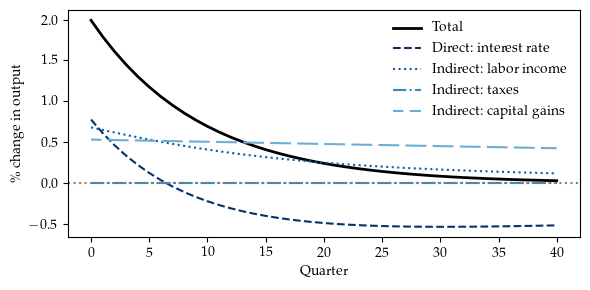

In [58]:
plt.plot(irfs_stock_only['C'][:41], label='Total', color='black', linewidth=2)
plt.plot(dC_r[:41], label='Direct: interest rate', linestyle='dashed', color=colors[0])
plt.plot(dC_labor[:41], label='Indirect: labor income', linestyle='dotted', color=colors[1])
plt.plot(dC_tax[:41], label='Indirect: taxes', linestyle='dashdot', color=colors[2])
plt.plot(dC_cap_gains[:41], label='Indirect: capital gains', linestyle=(5, (10, 3)), color=colors[3])
plt.axhline(y=0, linestyle='dotted', color='gray')
plt.legend(frameon=False)
plt.tight_layout()
plt.xlabel('Quarter')
plt.ylabel(r'\% change in output')
plt.tight_layout()
plt.savefig('figures/lecture6_decomposition_stock_only.pdf', transparent=True, bbox_inches='tight')

Add representative-agent response to check Werning neutrality result (version 2)

In [59]:
# Calculate representative-agent response 
dlogCra = np.empty(T)
dlogCra[-1] = 0
for t in reversed(range(T - 1)):
    dlogCra[t] = dlogCra[t + 1] - calib['eis'] * dr[t] / (1+calib['r'])

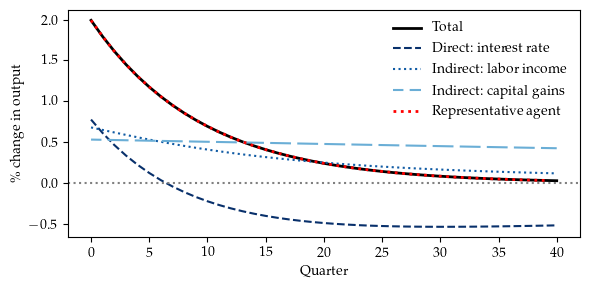

In [60]:
plt.plot(irfs_stock_only['C'][:41], label='Total', color='black', linewidth=2)
plt.plot(dC_r[:41], label='Direct: interest rate', linestyle='dashed', color=colors[0])
plt.plot(dC_labor[:41], label='Indirect: labor income', linestyle='dotted', color=colors[1])
#plt.plot(dC_tax[:41], label='Indirect: taxes', linestyle='dashdot', color=colors[2])
plt.plot(dC_cap_gains[:41], label='Indirect: capital gains', linestyle=(5, (10, 3)), color=colors[3])
plt.plot(dlogCra[:40]*ss_stock_only['C'], label='Representative agent', color='red', linestyle='dotted', linewidth=2)
plt.axhline(y=0, linestyle='dotted', color='gray')
plt.legend(frameon=False)
plt.tight_layout()
plt.xlabel('Quarter')
plt.ylabel(r'\% change in output')
plt.tight_layout()
plt.savefig('figures/lecture6_decomposition_stock_only_withra.pdf', transparent=True, bbox_inches='tight')